In [1]:
import pandas as pd

# Load the raw file
df = pd.read_csv("data/raw_worldbank_data.csv")

# Melt year columns into rows: one row per country-series-year
year_cols = [c for c in df.columns if "[YR" in c]
long_df = df.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# Clean the Year column: "2000 [YR2000]" -> 2000
long_df["Year"] = long_df["Year"].str.extract(r"(\d{4})").astype(int)

# World Bank uses ".." for missing values -> convert to real NaN, and make Value numeric
long_df["Value"] = pd.to_numeric(long_df["Value"], errors="coerce")

long_df.head()

,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Kenya,KEN,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.ZS,2000,2.884000
1,Kenya,KEN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2000,0.599695
2,Kenya,KEN,GDP per capita (current US$),NY.GDP.PCAP.CD,2000,414.626365
3,Kenya,KEN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2000,9.980025
4,Kenya,KEN,"Labor force participation rate, total (% of to...",SL.TLF.CACT.ZS,2000,72.512000


In [2]:
# Pivot so each row = one country-year, each indicator = its own column
wide_df = long_df.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

wide_df.columns.name = None  # cleanup column index label
wide_df.head()

,Country Name,Country Code,Year,GDP growth (annual %),GDP per capita (current US$),"Inflation, consumer prices (annual %)","Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)","Literacy rate, youth total (% of people ages 15-24)",Population growth (annual %),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
0,Burundi,BDI,2000,-0.856864,134.537862,24.432024,82.655,73.330002,2.077616,3.137,8.043814
1,Burundi,BDI,2001,2.055807,132.159555,9.296188,81.858,NaN,2.505687,3.154,8.241073
2,Burundi,BDI,2002,4.446519,120.952309,-1.365680,81.042,NaN,2.820219,3.168,8.451083
3,Burundi,BDI,2003,-1.223728,111.406683,10.647465,80.201,NaN,3.159093,3.145,8.676143
4,Burundi,BDI,2004,4.833658,125.194965,8.176429,79.346,NaN,3.727693,3.177,8.918555


In [3]:
# Check how much data is missing per column, and per country
print("Missing values per column:")
print(wide_df.isna().sum())

print("\nRows per country:")
print(wide_df["Country Name"].value_counts())

Missing values per column:
Country Name                                                                                       0
Country Code                                                                                       0
Year                                                                                               0
GDP growth (annual %)                                                                             31
GDP per capita (current US$)                                                                      16
Inflation, consumer prices (annual %)                                                             34
Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)      0
Literacy rate, youth total (% of people ages 15-24)                                              170
Population growth (annual %)                                                                       0
Unemployment, total (% of total labor force) (modeled ILO estima

In [4]:
# Drop literacy rate - too many missing values to be usable
clean_df = wide_df.drop(columns=["Literacy rate, youth total (% of people ages 15-24)"])

# Sort so interpolation happens in correct year order within each country
clean_df = clean_df.sort_values(["Country Name", "Year"])

# Fill small gaps using each country's own trend (interpolate), then fill any
# remaining edge gaps (e.g. missing in year 2000) using nearest known value
cols_to_fill = ["GDP growth (annual %)", "GDP per capita (current US$)", "Inflation, consumer prices (annual %)"]

for col in cols_to_fill:
    clean_df[col] = clean_df.groupby("Country Name")[col].transform(
        lambda s: s.interpolate().bfill().ffill()
    )

# Confirm no missing values remain
clean_df.isna().sum()

Country Name                                                                                      0
Country Code                                                                                      0
Year                                                                                              0
GDP growth (annual %)                                                                             0
GDP per capita (current US$)                                                                      0
Inflation, consumer prices (annual %)                                                            24
Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)     0
Population growth (annual %)                                                                      0
Unemployment, total (% of total labor force) (modeled ILO estimate)                               0
Urban population (% of total population)                                                          0


In [5]:
# Find which country has zero inflation data
missing_inflation = clean_df[clean_df["Inflation, consumer prices (annual %)"].isna()]
missing_inflation["Country Name"].unique()

array(['Somalia, Fed. Rep.'], dtype=object)

In [6]:
# Calculate average inflation per year across all other countries
yearly_avg_inflation = (
    clean_df[clean_df["Country Name"] != "Somalia, Fed. Rep."]
    .groupby("Year")["Inflation, consumer prices (annual %)"]
    .mean()
)

# Fill Somalia's missing inflation values using that year's regional average
mask = clean_df["Country Name"] == "Somalia, Fed. Rep."
clean_df.loc[mask, "Inflation, consumer prices (annual %)"] = clean_df.loc[mask, "Year"].map(yearly_avg_inflation)

# Confirm no missing values remain anywhere
clean_df.isna().sum()

Country Name                                                                                     0
Country Code                                                                                     0
Year                                                                                             0
GDP growth (annual %)                                                                            0
GDP per capita (current US$)                                                                     0
Inflation, consumer prices (annual %)                                                            0
Labor force participation rate, total (% of total population ages 15+) (modeled ILO estimate)    0
Population growth (annual %)                                                                     0
Unemployment, total (% of total labor force) (modeled ILO estimate)                              0
Urban population (% of total population)                                                         0
dtype: int

In [7]:
clean_df.to_csv("data/clean_unemployment_data.csv", index=False)
clean_df.shape

(216, 10)

In [9]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 4.6 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.3 MB 5.4 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.3 MB 5.7 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.3 MB 5.7 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.3 MB 5.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.3 MB 5.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.3 MB 5.6 MB/s eta 0:00:01
   -------------------------------------- - 8.9/9.3 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 5.3 MB/s  0:00:01
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 6.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.2 MB 6.1 MB/s eta 0:00:01
   ----------------- --------

Matplotlib is building the font cache; this may take a moment.
C:\Users\user1\AppData\Local\Temp\ipykernel_25048\144663093.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


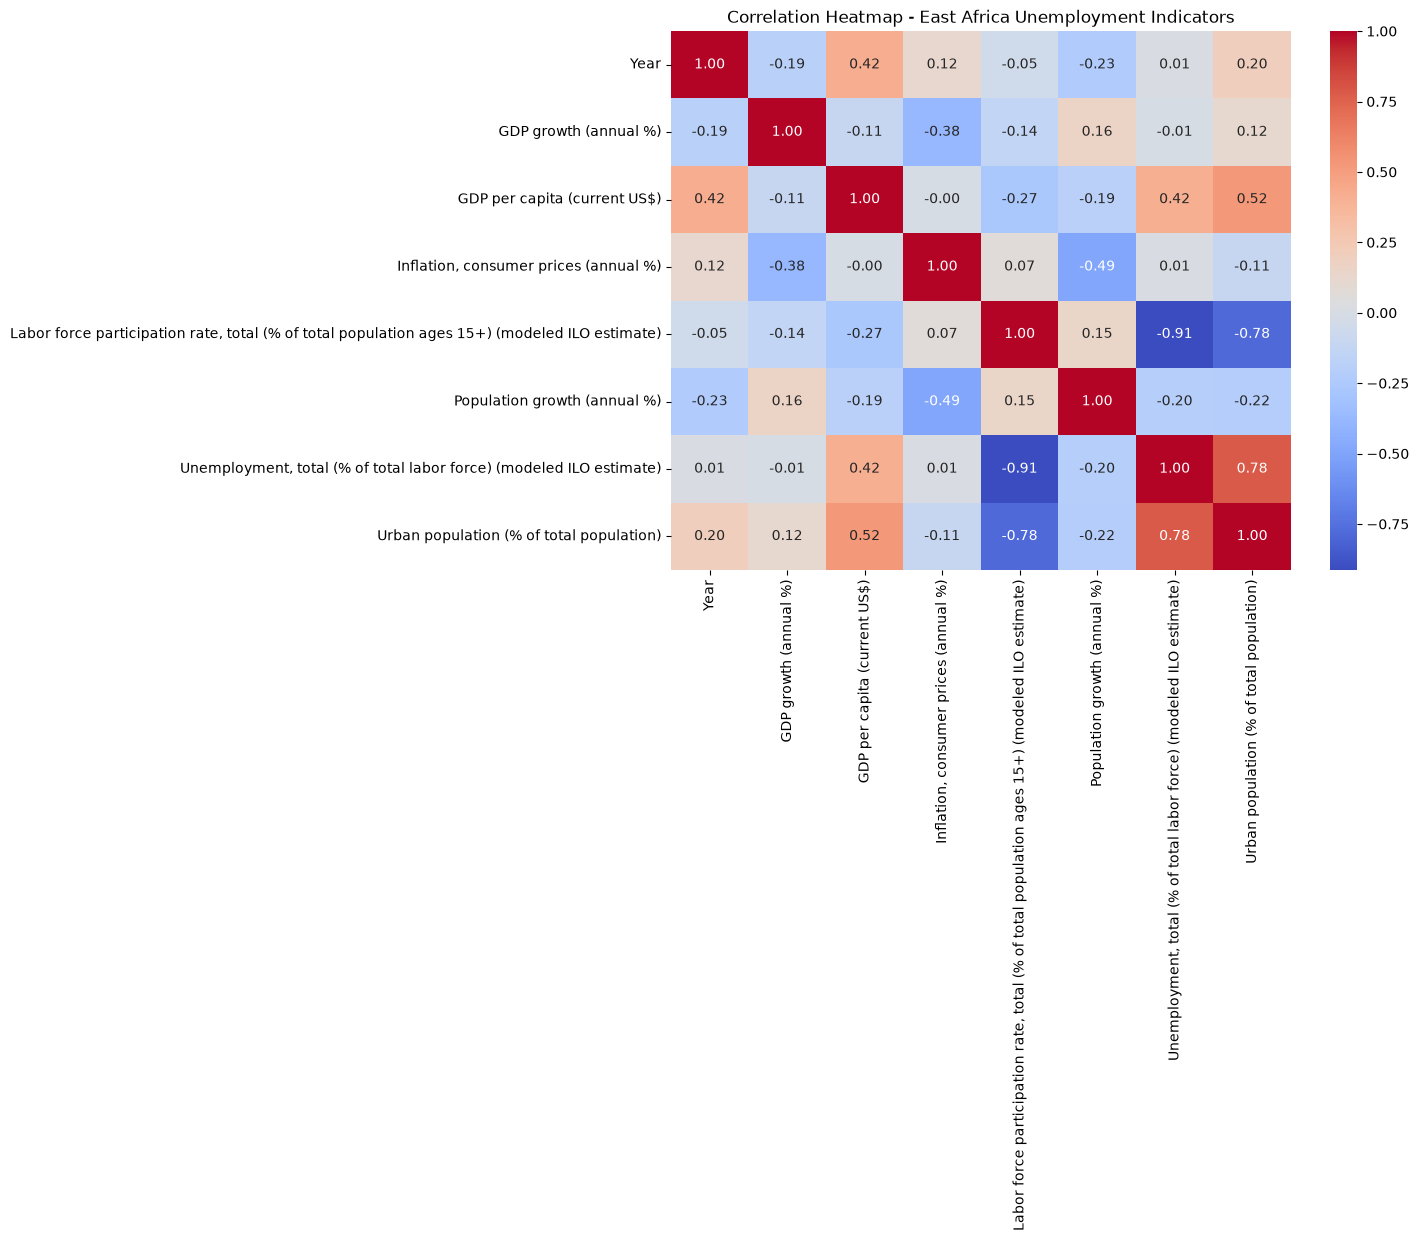

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the numeric columns (drop Country Name/Code, keep Year)
numeric_cols = clean_df.select_dtypes(include="number")

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - East Africa Unemployment Indicators")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

## Correlation Heatmap Interpretation

The heatmap shows labor force participation rate has the strongest relationship with unemployment 
(-0.91), meaning countries with higher participation tend to have lower unemployment. Urban population 
percentage is also strongly correlated (0.78), suggesting urbanization patterns matter for this region's 
labor market. GDP per capita shows a moderate positive correlation (0.42). Inflation and GDP growth show 
weak correlation with unemployment individually, but may still contribute in combination with other features.

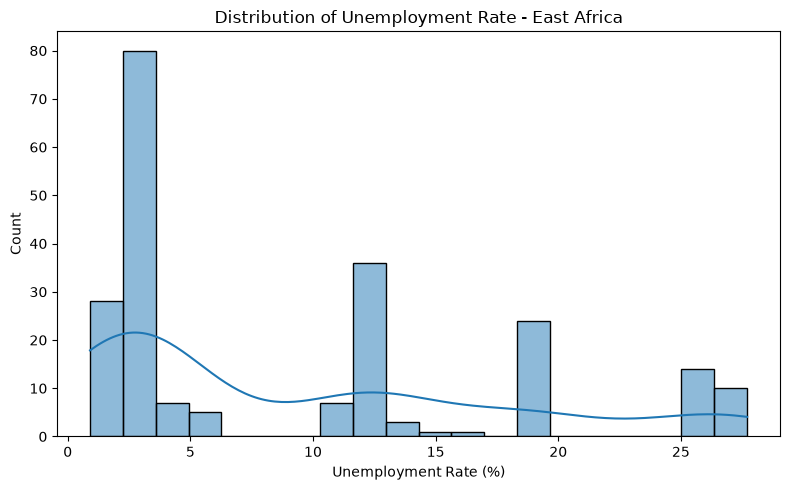

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(clean_df["Unemployment, total (% of total labor force) (modeled ILO estimate)"], kde=True, bins=20)
plt.title("Distribution of Unemployment Rate - East Africa")
plt.xlabel("Unemployment Rate (%)")
plt.tight_layout()
plt.savefig("unemployment_distribution.png")
plt.show()

## Unemployment Distribution Interpretation

The distribution is multi-modal rather than a single bell curve, with distinct clusters around 2-4%, 
12%, 18-20%, and 25-27%. This pattern reflects that unemployment rates differ substantially by country 
rather than forming one continuous population - each East African country tends to sit within its own 
fairly stable unemployment band over the 2000-2023 period. This suggests country identity itself carries 
predictive information and should be considered during feature engineering.